In [4]:
import numpy as np
import math
import pandas as pd

In [13]:
X = [0.1,0.2,0.4,0.6,0.9,1.3,1.5,1.7,1.8]
y = [0.75,1.25,1.45,1.25,0.85,0.55,0.35,0.28,0.18]

In [14]:
X = np.array(X)
y = np.array(y)

In [15]:
#1
#y = a * X * e **(B*X) 將X移項左右同取ln，線性化
# ln (y/x) = ln (a) + B * X
# 可看成  y = B0 + B1 * X + e 簡單線性回歸。 y = ln(y/x) 。 B0 = ln (a) 。B1 = B
#直接用OLS法，求其線性化模型

In [16]:
#根據直接線性化轉換 對y取ln
y = np.log(y/X)
X = np.log(X)

In [17]:
y

array([ 2.01490302,  1.83258146,  1.28785429,  0.73396918, -0.05715841,
       -0.86020127, -1.45528723, -1.80359393, -2.30258509])

In [18]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
X = sm.add_constant(X) # add constant

# fitting model - OLS linear regression
reg = sm.OLS(y, X).fit()
reg.summary()

C:\Users\James\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     56.81
Date:                Wed, 23 Nov 2022   Prob (F-statistic):           0.000133
Time:                        22:34:07   Log-Likelihood:                -6.6365
No. Observations:                   9   AIC:                             17.27
Df Residuals:                       7   BIC:                             17.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6748      0.207     -3.253      0.014      -1.165      -0.184
x1            -1.4936      0.198     -7.537      0.000      -1.962      -1.025
==============================================================================
Omnibus:                        1.413   Durbin-Watson:                   0.613
Prob(Omnibus):                  0.493   Jarque-Bera (JB):                0.751
Skew:                          -0.257   Prob(JB):                        0.687
Kurtosis:                       1.681   Cond. No.                         1.51
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
# y*= -0.6748 -1.4936X
# Ci for B0 = [-1.165	-0.184]
# Ci for B1 = [-1.962	-1.025]

In [23]:
import matplotlib.pyplot as plt

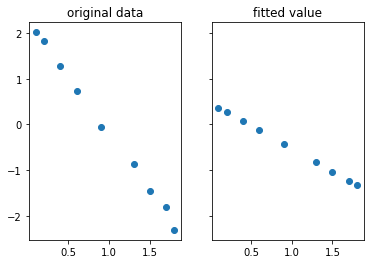

In [21]:
import matplotlib.pyplot as plt
X = [0.1,0.2,0.4,0.6,0.9,1.3,1.5,1.7,1.8]
X = np.array(X)
y_fit = X * -0.9993 + 0.4696
# Create two subplots and unpack the output array immediately
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.scatter(X, y)
ax1.set_title('original data')
ax2.scatter(X, y_fit)
ax2.set_title('fitted value')
plt.show()

In [10]:
#2

In [11]:
X = [0.1,0.2,0.4,0.6,0.9,1.3,1.5,1.7,1.8]
y = [0.75,1.25,1.45,1.25,0.85,0.55,0.35,0.28,0.18]
X = np.array(X)
y = np.array(y)

In [12]:
p = np.array([1,1]) # initial guess p = theta_hat = [a_hat, B_hat]

In [13]:
J = np.zeros([len(X),len(p)]) #set shape of Jacobin
J

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [14]:
Iter = 0

In [15]:
while True:
    Iter+=1
    j1 = -X * np.exp(p[1]*X) # a對r偏微分
    j2 = - p[0]*X*X*np.exp(p[1]*X) # B對r偏微分
    J[:,0] = j1 #set Jacobin col0
    J[:,1] = j2 #set Jacobin col1
    r = y - (p[0]*X*np.exp(p[1]*X)) #殘差
    
    # theta_k+1 = theta_k + (Z'Z)-1 * Z' * (residual)
    
    t1 = np.linalg.inv(np.dot(J.T,J)) #求(Z'Z)-1
    t2 = np.dot(t1,J.T) # 求(Z'Z)-1 * Z'
    t3 = np.dot(t2,r) # (Z'Z)-1 * Z' * (residual)
    p2 = p - t3 # 得出 theta_k+1
    t4 = abs(p2-p)
    if max(t4) <= 0.00001: # 收斂條件 p2 - p <= 1e-5，
        break
    p = p2 # or 繼續迭代
    
a = p[0]
B = p[1]

In [32]:
Iter

10

In [16]:
a 

9.897361049405893

In [17]:
B

-2.531869134482962

In [18]:
pred = a * X *np.exp(B*X)

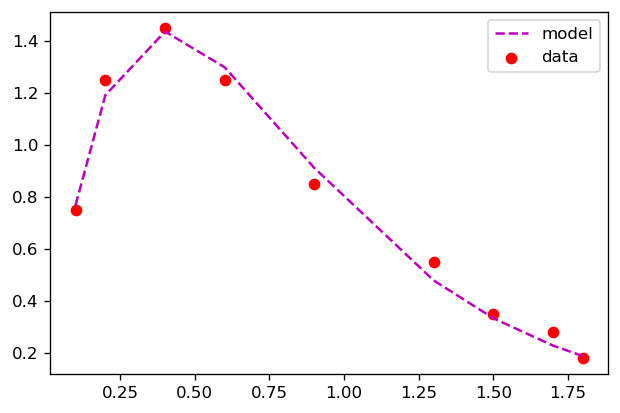

In [19]:
plt.figure(1,figsize=(6,4),dpi=120)
plt.scatter(x=X,y=y,c='red',marker='o',label = 'data')
plt.plot(X,pred,'--m',label ='model')
plt.legend()

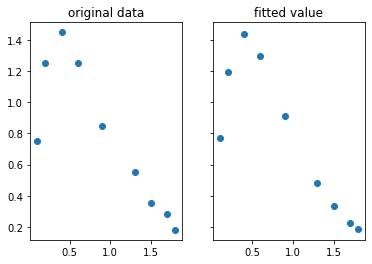

In [20]:

# Create two subplots and unpack the output array immediately
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.scatter(X, y)
ax1.set_title('original data')
ax2.scatter(X,pred)
ax2.set_title('fitted value')
plt.show()

In [21]:
t1 # 最後一組 (Z Z')-1

array([[45.76962518, -6.37233643],
       [-6.37233643,  1.27552152]])

In [22]:
sse = np.sum((y-pred)**2)

In [23]:
sse

0.018315258899587898

In [24]:
sigma2 = sse / (9-2)

In [25]:
se_a = (sigma2*45.76962518)**0.5
se_b = (sigma2*1.27552152)**0.5

In [26]:
# create CI

a_CI = [a-se_a* 2.365 , a+se_a*2.365]
B_CI = [B-se_b*2.365 , B+se_b*2.365]

In [27]:
print(a_CI)

print(B_CI)

[9.078938976030612, 10.715783122781174]
[-2.6684948820393575, -2.3952433869265666]


In [28]:
#3===================================================

In [29]:
#第一題之sse
np.sum((y-y_fit)**2)

14.9132652905

In [30]:
#第二題之sse
sse

0.018315258899587898

In [31]:
#選擇第二題model 